# Equity analysis walkthrough

This notebook demonstrates the equity-analysis half of `transitlos`: joining
population data onto a transit-access-score layer with
`transitlos.cross_with_population`, then computing population-weighted
equity statistics with `transitlos.equity_statistics`.

"Equity" here means: access to transit isn't just about how good the average
street edge scores, but about how that score is *distributed across the
people* who actually live there. A neighborhood-average `level_of_service` can
look fine while the population living in the worst-served areas is
concentrated in one group. `equity_statistics` reports population-weighted
means/medians, a Gini coefficient of access inequality, the share of
population above/below chosen score thresholds, and (optionally) all of the
above broken down by group.

This notebook recomputes a small `compute_level_of_service` result at the
top so it is runnable standalone, continuing from
`transit_level_of_service_walkthrough.ipynb` in spirit rather than requiring
its output to already exist in memory.


## 1. Imports


In [1]:
import matplotlib.pyplot as plt
import numpy as np

import transitlos
from transitlos import compute_level_of_service, cross_with_population, equity_statistics
from UrbanAccessAnalyzer.api import AreaOfInterest
from pyGTFSHandler.utils.geocoding import get_city_geometry


## 2. Recompute (or reuse) the access-score layer

Same AOI, feed, and region as the level-of-service walkthrough -- see that
notebook for a full explanation of this call. If you already have
`access_gdf` in memory from that notebook, skip straight to step 3.


**Explicit `date_range` to skip auto-date-detection.** As in
`transit_level_of_service_walkthrough.ipynb`, if `date_range` is omitted
`compute_level_of_service` falls back to `download_and_prepare_stops`'s
`Feed.get_representative_date` auto-detection: dates are grouped into
calendar weeks, the week with the highest **median** daily service
intensity is picked, and within it the weekday closest to that week's
weekday median is returned (see
`pyGTFSHandler.utils.processing_helpers.select_representative_date` for the
full algorithm). That auto-detection, run once already, picked **Friday,
2026-08-21** as the representative date across all downloaded feeds (a
normal MBTA weekday, within `mdb-437_massachuse`'s 2026-07-31 to
2026-09-05 weekday `calendar.txt` range). We pass that date explicitly
below to keep this notebook fast -- `transit_level_of_service_walkthrough.ipynb`
has a dedicated cell exercising the auto-detection fallback for real.


In [2]:
import glob
from datetime import date

from pyGTFSHandler.utils.geocoding import get_geographic_suggestions_from_string
from pyGTFSHandler.downloaders.mobility_database import MobilityDatabaseDownloader

city_name = "Cambridge, Massachusetts, USA"
aoi = AreaOfInterest(get_city_geometry(city_name))

# Reuse the same Mobility Database search/download flow as the
# pyGTFSHandler Cambridge example notebook, so this notebook is runnable
# standalone (see transit_level_of_service_walkthrough.ipynb section 3 for
# a full explanation).
geo_suggestions = get_geographic_suggestions_from_string(city_name)
api = MobilityDatabaseDownloader("")  # reads the refresh token from api_keys.json
feeds = api.search_feeds(
    country_code=geo_suggestions["country_codes"],
    subdivision_name=geo_suggestions["subdivision_names"],
    municipality=geo_suggestions["municipalities"],
    is_official=True,
)
api.download_feeds(feeds=feeds, download_folder="outputs/orig_gtfs_files", overwrite=False)
feed_source = sorted(glob.glob("outputs/orig_gtfs_files/*"))

# Explicit, known-good service date (see markdown note above) -- skips
# download_and_prepare_stops's ~7s auto-detection fallback.
analysis_date = date(2026, 8, 21)

access_gdf = compute_level_of_service(
    aoi,
    feed_source=feed_source,
    region="north_america",
    cache_dir="./_network_cache",
    pbf_path="./us_massachusetts.osm.pbf",
    date_range=(analysis_date, analysis_date),
)
access_gdf.head()


/home/miguel/Documents/Proyectos/AccessibilityMIT/pyGTFSHandler/pyGTFSHandler/models/stop_times.py:199: UserWarning: Some departure times are null and have been interpolated
  warnings.warn("Some departure times are null and have been interpolated")


/home/miguel/Documents/Proyectos/AccessibilityMIT/pyGTFSHandler/pyGTFSHandler/models/shapes.py:1325: RuntimeWarning: direction_id assignment: 1 of 132 shape_ids (0.8%) had at least one stop where the geometry disagreed with their reported direction_id (direction_conflict=True), across 1 of 302 stop(s) (0.3%).
  warnings.warn(


[isochrones] tier level_of_service=0.992 distance=400.0 n_sources=4
[isochrones] tier level_of_service=0.987 distance=800.0 n_sources=4
[isochrones] tier level_of_service=0.982 distance=1200.0 n_sources=4
[isochrones] tier level_of_service=0.972 distance=400.0 n_sources=5
[isochrones] tier level_of_service=0.967 distance=800.0 n_sources=5
[isochrones] tier level_of_service=0.962 distance=1200.0 n_sources=5
[isochrones] tier level_of_service=0.952 distance=400.0 n_sources=4
[isochrones] tier level_of_service=0.947 distance=800.0 n_sources=4
[isochrones] tier level_of_service=0.942 distance=1200.0 n_sources=4
[isochrones] tier level_of_service=0.932 distance=400.0 n_sources=4
[isochrones] tier level_of_service=0.927 distance=800.0 n_sources=4
[isochrones] tier level_of_service=0.922 distance=1200.0 n_sources=4
[isochrones] tier level_of_service=0.912 distance=400.0 n_sources=4
[isochrones] tier level_of_service=0.907 distance=800.0 n_sources=4
[isochrones] tier level_of_service=0.902 dis

,u,v,length_m,highway,edge_uid,oneway,level_of_service,geometry
0,61317367.0,NaN,13.116382,residential,541,True,0.992,"LINESTRING (326941.267 4692809.478, 326953.547..."
1,61317413.0,NaN,30.366023,residential,553,False,0.992,"LINESTRING (326499.372 4692982.975, 326522.226..."
2,61321194.0,NaN,85.550940,residential,554,True,0.992,"LINESTRING (326439.457 4692921.907, 326499.372..."
3,61317416.0,NaN,42.260110,residential,555,False,0.992,"LINESTRING (326961.929 4692659.775, 326999.752..."
4,61328503.0,NaN,71.699954,residential,556,True,0.992,"LINESTRING (326927.048 4692597.131, 326961.929..."


## 3. Join population data

`transitlos.cross_with_population` aggregates `access_gdf`'s `level_of_service`
(street-edge geometry) onto a population layer's own polygons -- by default
`population_source="worldpop"`, a global gridded raster (any country),
vectorized into a per-pixel polygon grid. `aoi` and `worldpop_date` are
required for the WorldPop path; `worldpop_resolution="1km"` keeps the
per-pixel vectorization tractable.

For US locations, `population_source="us_census"` (ACS or decennial/DHC,
tract or blockgroup level) is an alternative that gives real administrative
geographies instead of raster pixels -- pass `region_for_census` (or let it
default from `aoi`).


In [3]:
combined_gdf = cross_with_population(
    access_gdf,
    population_source="worldpop",
    aoi=aoi.gdf,
    worldpop_date=2020,
    worldpop_resolution="1km",
    worldpop_folder="./_worldpop_cache",
)
combined_gdf.head()


Raster population path ./_worldpop_cache/usa_pop_2020_CN_1km_R2025A_UA_v1.tif exists. Skipping download...


,edge_id,geometry,level_of_service,population
0,0,"POLYGON ((-71.175 42.41667, -71.175 42.425, -7...",0.0,2136.710693
1,1,"POLYGON ((-71.16667 42.41667, -71.16667 42.425...",0.0,2500.754395
2,2,"POLYGON ((-71.15833 42.41667, -71.15833 42.425...",0.0,1831.878540
3,3,"POLYGON ((-71.15 42.41667, -71.15 42.425, -71....",0.0,1961.412842
4,4,"POLYGON ((-71.14167 42.41667, -71.14167 42.425...",0.0,1177.176270


## 4. Compute population-weighted equity statistics

`region` in `compute_level_of_service`/`compute_stop_scores` should match
where the AOI actually is -- see `report/scoring/SCORING.md` section 3 for
why the regional parameter tables differ (e.g. section 3.2 for North
America, used above); the same regional lens matters here when interpreting
`equity_statistics`' output, since what counts as "good" access is itself
region-relative.

`thresholds` below reports the population share scoring above/below
low/medium/high access-score cutoffs.


In [4]:
stats = equity_statistics(
    combined_gdf,
    score_col="level_of_service",
    population_col="population",
    thresholds=(0.25, 0.5, 0.75),
)
stats["overall"]


{'weighted_mean': 0.2536536868650933,
 'weighted_median': 0.0,
 'gini': 0.7283994513452103,
 'pct_population_above_threshold': {0.25: 0.2982890882938923,
  0.5: 0.2859503339433762,
  0.75: 0.23301403903766854},
 'pct_population_below_threshold': {0.25: 0.7017109117061078,
  0.5: 0.7140496660566238,
  0.75: 0.7669859609623315}}

## 5. Visualize: population share above/below each threshold

A simple, clearly-labeled bar chart of the population share above vs. below
each score threshold -- the headline equity number: what fraction of the
people in this AOI live somewhere with meaningfully good/bad transit access.


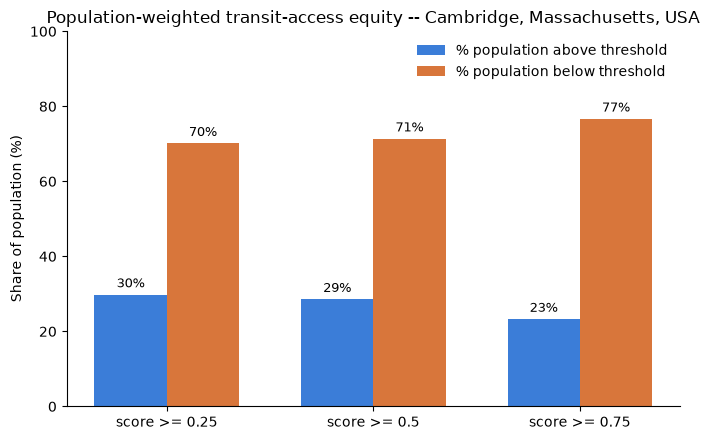

In [5]:
thresholds = list(stats["overall"]["pct_population_above_threshold"].keys())
above = [stats["overall"]["pct_population_above_threshold"][t] * 100 for t in thresholds]
below = [stats["overall"]["pct_population_below_threshold"][t] * 100 for t in thresholds]

x = np.arange(len(thresholds))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4.5))
bars_above = ax.bar(x - width / 2, above, width, label="% population above threshold", color="#3b7dd8")
bars_below = ax.bar(x + width / 2, below, width, label="% population below threshold", color="#d8763b")

ax.set_xticks(x)
ax.set_xticklabels([f"score >= {t}" for t in thresholds])
ax.set_ylabel("Share of population (%)")
ax.set_title(f"Population-weighted transit-access equity -- {city_name}")
ax.set_ylim(0, 100)
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bars in (bars_above, bars_below):
    ax.bar_label(bars, fmt="%.0f%%", padding=3, fontsize=9)

fig.tight_layout()


## 6. Optional: break down by group

If `combined_gdf` has a categorical column to group by (e.g. a neighborhood
name, an income-tercile bucket derived from census data, etc.), pass it as
`groups=` to see per-group weighted mean/median/Gini and threshold shares
side by side, e.g.:

```python
equity_statistics(combined_gdf, groups="neighborhood")["by_group"]
```
